# BIL Data Python API

Welcome! This notebook introduces the `bil` data API for accessing publicly released data from the [Brain Interfacing Lab](https://bil.stanford.edu/).

This package lets you interact with data publicly deposited to the [Stanford Digital Repository (SDR)](https://purl.stanford.edu/zz618yg1930). It uses the `requests` package to download files over HTTPS upon access.


First, install the package!

**Via HTTPS:**
```bash
pip install git+https://github.com/bil/data-python.git
```

**Via SSH:**
```bash
pip install git+ssh://git@github.com/bil/data-python.git
```

## Data Availability Disclaimer

1. **Incremental Releases:** The public deposition in the [SDR](https://purl.stanford.edu/zz618yg1930) is being expanded incrementally and only contains data associated with formal publications.
2. **Missing Files:** Because of this, many API methods **will not work** until the corresponding data has been released. These will fail with a `FileNotFoundError`.

## The Study

The entry point is the `Study` object. If you have a session ID from a paper or in the SDR (it will look something like "U201130_01", meaning the first session by subject "U" on 2020-11-30), you can initialize a `Study` pointing to that session.

The initialization will automatically choose the correct format. Below, you'll see that we end up with an object from `dataclassA`.

The full set of constructor arguments is:
- `study_id`: The session identifier (e.g., "U201130_01").
- `download_dir`: The local directory where data will be stored. By default, this is a relative path: "data".
- `quiet`: A flag to suppress progress bars and print statements during data transfer (defaults to `False`).

Useful attributes of the resultant object include:
- `url`: The remote HTTPS endpoint from which data will be fetched. This is set from a constant.
- `has`: A set of data (either a semantic name or a path string) that has been downloaded by this object. It will be empty at first.

Instantiation prepares the `download_dir` but **does not download anything yet**.

In [1]:
import os
import numpy as np
from bil.dataclass import Study

study = Study("U201130_01", download_dir="tmp")
print(f"Study came from class: {study.__class__}\n")

print(f"Study ID: {study.study_id}")
print(f"Local Cache Directory: {study.download_dir}")
print(f"Remote URL: {study.url}")
print(f"Set of downloaded data: {study.has}")

Copying U201130_01.yaml to tmp...
Found local file!
Study came from class: <class 'bil.dataclass.dataclassA.Study'>

Study ID: U201130_01
Local Cache Directory: tmp/U201130_01
Remote URL: https://stacks.stanford.edu/v2/file/zz618yg1930/version/2/data//U201130_01
Set of downloaded data: set()


## Accessing Metadata

For some sessions, data is organized into trials. This example is one of those. Specifically, this dataset features subject U performing radial, center-out reaches to 8 targets.

The number of trials defines the `Study`'s length. Each trial has associated metadata, which is fetched from the server when you access attributes such as the length or the `df` property.

In [2]:
# Fetch trial metadata and create Span objects
num_trials = len(study)
print(f"Total number of trials: {num_trials}")

# The trial metadata is available as a pandas DataFrame
display(study.df.head())

Copying df/trial.df.xz to tmp/U201130_01...
Found local file!
Total number of trials: 1500


,study,number,trial_id,ms_start,ms_end,success,quality,target_loc_x,target_loc_y,target_loc,...,pe_cursor_offset_y,pe_task_toggle,pe_juice_toggle,pe_time_max_last_success,pe_cursor_offset_x_toggle,pe_z_window_toggle,pe_target_color_value,pe_task_automation,pe_target_stack_on,pe_radius_target
0,U201130_01,0,U201130_01_0,759,1330,True,1.0,0,0,center,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,U201130_01,1,U201130_01_1,1345,2013,True,1.0,100,0,right,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,U201130_01,2,U201130_01_2,2028,2680,True,1.0,0,0,center,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,U201130_01,3,U201130_01_3,2695,3446,True,1.0,0,-100,bottom,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,U201130_01,4,U201130_01_4,3461,4263,True,1.0,0,0,center,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


The columns of this DataFrame can be accessed by string indexing:

In [3]:
print(f"Target locations: {study['target_loc'].unique()}")

Target locations: ['center' 'right' 'bottom' 'bottom_right' 'top_left' 'bottom_left' 'top'
 'top_right' 'left']


## Spans

A `Study` object is a wrapper used to retrieve `Span` objects. A `Span` is an abstraction for any continuous segment of time, using units of milliseconds. Most of our data signals are sampled or binned at 1kHz, so accessing a `Span`'s data returns a timepoint for each millisecond. This also means the smallest `Span` you can have is 1 millisecond long (the largest is the length of the session).

Because this session has a trial structure, it already holds a list of `Span` objects corresponding to each trial duration. These are accessible via `study.spans`. These are iterated over when iterating through the `Study` and can be accessed via integer indexing.

In [4]:
# Get the span for the very first trial
first_trial_span = study.spans[0]

print(f"Trial Start: {first_trial_span.start} ms")
print(f"Trial End: {first_trial_span.stop} ms")

Trial Start: 759 ms
Trial End: 1330 ms


The length of a `Span` is its duration in milliseconds:

In [5]:
print(len(first_trial_span))
print(first_trial_span.stop - first_trial_span.start)

571
571


A `Span` has a `metadata` attribute:

In [6]:
print(first_trial_span.metadata["target_loc"])

center


Another way to get a span is to index by time. Specifically, you can get the first 100ms of the whole session by:

In [7]:
print(study.by_time(slice(None, 100)))

Copying U201130_01.h5 to tmp/U201130_01...
Found local file!
span(study_id=U201130_01, start=0ms, stop=100ms)


Or the whole session by:

In [8]:
print(study.by_time(slice(None, None)))

span(study_id=U201130_01, start=0ms, stop=1359000ms)


## Accessing Data

Now let's retrieve some actual neural and behavioral data for our trial! 

When you call these methods, the object checks if the requested file is cached locally. If not, it will be downloaded automatically. Once downloaded, it returns data from the requested span of time.

Copying signal/pos_cursor_x.h5 to tmp/U201130_01...
Found local file!
Copying signal/pos_cursor_y.h5 to tmp/U201130_01...
Found local file!
Kinematics shape (dimensions, time): (2, 571)
Copying neural/lfp_1k.h5 to tmp/U201130_01...
Found local file!
LFP shape (channels, time): (96, 571)


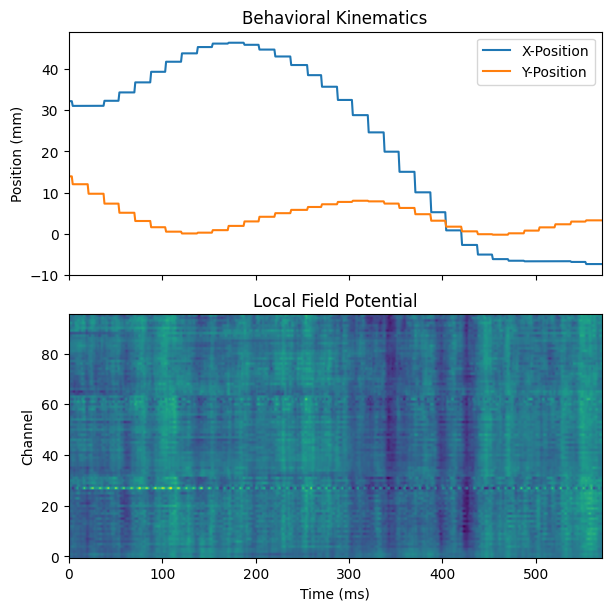

In [9]:
import matplotlib.pyplot as plt

# 1. Fetch Cursor Kinematics (2D position)
kinematics = first_trial_span.kinematics()
print("Kinematics shape (dimensions, time):", kinematics.shape)

# 2. Fetch Local Field Potential (LFP) data for a specific brain region ('m1')
# Note: This will download the lfp_1k.h5 file the first time!
lfp = first_trial_span.lfp(region="m1")
print("LFP shape (channels, time):", lfp.shape)

# Plot the data
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True, layout="constrained")

# Plot cursor position
axs[0].plot(kinematics[0, :], label="X-Position")
axs[0].plot(kinematics[1, :], label="Y-Position")
axs[0].set_ylabel("Position (mm)")
axs[0].legend()
axs[0].set_title("Behavioral Kinematics")

# Plot LFP
axs[1].imshow(lfp, aspect="auto", cmap="viridis", origin="lower")
axs[1].set_ylabel("Channel")
axs[1].set_xlabel("Time (ms)")
axs[1].set_title("Local Field Potential")
plt.show()

To see all built-in data access functions, you can investigate the `DataCatalog` implementation in `bil.dataclass.dataclassA`. As mentioned earlier, many of those functions may not work if the corresponding data hasn't been deposited. For instance, the large raw data files will often not exist:

In [10]:
try:
    raw = first_trial_span.raw(region="m1")
except FileNotFoundError as e:
    print(f"Raw data doesn't exist for this session!\n\n{e}")

Copying neural/raw_ch001.h5 to tmp/U201130_01...
Raw data doesn't exist for this session!

Failed to download https://stacks.stanford.edu/v2/file/zz618yg1930/version/2/data//U201130_01/neural/raw_ch001.h5: 404 Client Error: Not Found for url: https://stacks.stanford.edu/v2/file/zz618yg1930/version/2/data//U201130_01/neural/raw_ch001.h5


## SpanSet and SpanArray

Just as integer indexing returns a trial `Span`, slice indexing returns a set of spans, or a `SpanSet`. This is a wrapper for a list of `Span` objects that returns data from each span, collected into a list.

In [11]:
spanset = study[:5]
print(f"Type: {type(spanset)}")
print(f"Length: {len(spanset)}")

Type: <class 'bil.dataclass.dataclassA.SpanSet'>
Length: 5


We can get the kinematics from these trials:

In [12]:
list_of_kinematics = spanset.kinematics()
for kinematics in list_of_kinematics:
    print(kinematics.shape)

(2, 571)
(2, 668)
(2, 652)
(2, 751)
(2, 802)


Since each `Span` can have a different length, these methods return lists of differently sized arrays. However, a `SpanArray` is a version of a `SpanSet` where each underlying `Span` has the same length! The easiest way to create one is with the `around` method. Here is an example of getting the 500 milliseconds surrounding the time the reaching target was acquired, using the DataFrame key `time_target_acquire_last`.

In [13]:
spanarray = spanset.around("time_target_acquire_last", t_before=250, t_after=249)
array_of_kinematics = spanarray.kinematics()
print(f"Shape: {array_of_kinematics.shape}")

Shape: (5, 2, 500)
